In [35]:
# Imports

In [36]:
import warnings
warnings.filterwarnings("ignore")

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.ndimage import uniform_filter1d

from statsmodels.tsa.stattools import adfuller, acf, pacf

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Optional if installed
try:
    from arch import arch_model
    ARCH_AVAILABLE = True
except Exception:
    ARCH_AVAILABLE = False

# Optional for deep models
try:
    from neuralforecast import NeuralForecast
    from neuralforecast.models import TCN, Autoformer
    from neuralforecast.losses.pytorch import MAE
    NF_AVAILABLE = True
except Exception:
    NF_AVAILABLE = False

In [37]:
import matplotlib as mpl
import matplotlib.pyplot as plt

def set_tableau_style():
    
    tableau_colors = [
        "#4E79A7", "#F28E2B", "#E15759", "#76B7B2",
        "#59A14F", "#EDC948", "#B07AA1", "#FF9DA7",
        "#9C755F", "#BAB0AC"
    ]

    mpl.rcParams.update({

        # Color cycle
        "axes.prop_cycle": mpl.cycler(color=tableau_colors),

        # Figure
        "figure.facecolor": "white",
        "figure.figsize": (10,6),

        # Axes
        "axes.facecolor": "white",
        "axes.edgecolor": "#CCCCCC",
        "axes.linewidth": 0.8,
        "axes.grid": True,
        "axes.axisbelow": True,
        "axes.titlesize": 16,
        "axes.titleweight": "semibold",
        "axes.labelsize": 12,

        # Gridlines
        "grid.color": "#E6E6E6",
        "grid.linestyle": "-",
        "grid.linewidth": 1.0,

        # Ticks
        "xtick.color": "#555555",
        "ytick.color": "#555555",
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,

        # Lines
        "lines.linewidth": 2.5,
        "lines.markersize": 6,

        # Fonts
        "font.family": "sans-serif",
        "font.size": 12,

        # Legend
        "legend.frameon": False,
        "legend.fontsize": 11
    })

set_tableau_style()

# Data Preparation

In [38]:
fred_path = "../data/raw/FRED.csv"
yields = pd.read_csv(fred_path)

maturity_cols = {
    'DGS1MO': '1M',
    'DGS3MO': '3M', 
    'DGS6MO': '6M',
    'DGS1': '1Y',
    'DGS2': '2Y',
    'DGS3': '3Y',
    'DGS5': '5Y',
    'DGS7': '7Y',
    'DGS10': '10Y',
    'DGS20': '20Y',
    'DGS30': '30Y'
}

yields = yields[['observation_date'] + list(maturity_cols.keys())]
yields = yields.rename(columns={'observation_date': 'date', **maturity_cols})
yields['date'] = pd.to_datetime(yields['date'])
yields = yields.set_index('date')

end_date = pd.Timestamp('2026-03-14')
start_date = end_date - pd.DateOffset(years=5)
yields = yields.loc[start_date:end_date]

for col in maturity_cols.values():
    yields[col] = pd.to_numeric(yields[col], errors='coerce')

yields = yields.dropna()

print("Yield curve data shape:", yields.shape)
print("Date range:", yields.index.min(), "to", yields.index.max())
print("Maturities:", list(yields.columns))

yields_diff = yields.diff().dropna()

print("Differenced data shape:", yields_diff.shape)

Yield curve data shape: (1232, 11)
Date range: 2021-03-15 00:00:00 to 2026-02-17 00:00:00
Maturities: ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
Differenced data shape: (1231, 11)


# Principal Component Analysis

We perform PCA on the covariance matrix of the differenced yield series. This aligns with fixed-income risk models that treat yield shocks as changes rather than levels.

Eigenvalues:
PC1: 0.027900
PC2: 0.004072
PC3: 0.003765
PC4: 0.001431
PC5: 0.000560
PC6: 0.000254
PC7: 0.000214
PC8: 0.000118
PC9: 0.000054
PC10: 0.000048
PC11: 0.000032

Proportion of variance explained:
PC1: 0.7256
PC2: 0.1059
PC3: 0.0979
PC4: 0.0372
PC5: 0.0146
PC6: 0.0066
PC7: 0.0056
PC8: 0.0031
PC9: 0.0014
PC10: 0.0012
PC11: 0.0008

Cumulative variance explained:
First 1 PCs: 0.7256
First 2 PCs: 0.8315
First 3 PCs: 0.9295
First 4 PCs: 0.9667
First 5 PCs: 0.9813
First 6 PCs: 0.9879
First 7 PCs: 0.9934
First 8 PCs: 0.9965
First 9 PCs: 0.9979
First 10 PCs: 0.9992
First 11 PCs: 1.0000


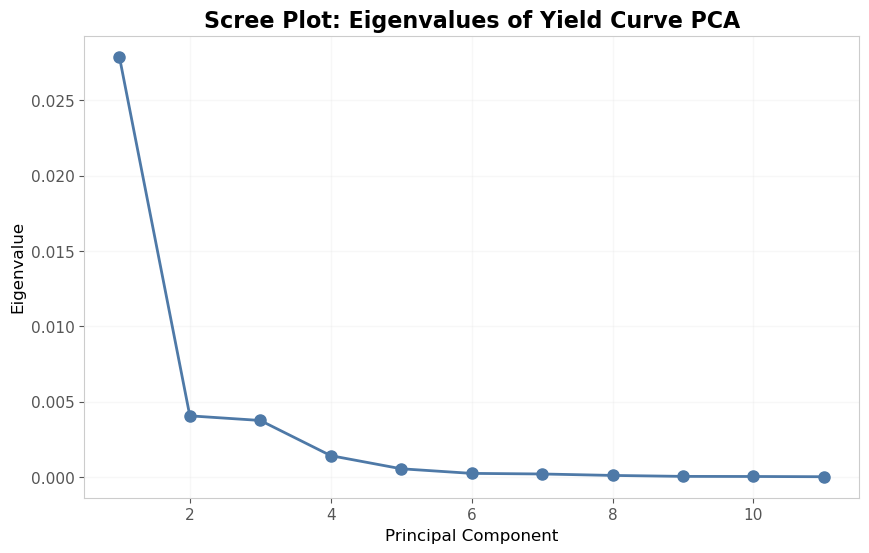

In [39]:
pca = PCA()
pca.fit(yields_diff)

eigenvalues = pca.explained_variance_
print("Eigenvalues:")
for i, ev in enumerate(eigenvalues, 1):
    print(f"PC{i}: {ev:.6f}")

explained_variance_ratio = pca.explained_variance_ratio_
print("\nProportion of variance explained:")
for i, ratio in enumerate(explained_variance_ratio, 1):
    print(f"PC{i}: {ratio:.4f}")

cumulative_variance = np.cumsum(explained_variance_ratio)
print("\nCumulative variance explained:")
for i, cum in enumerate(cumulative_variance, 1):
    print(f"First {i} PCs: {cum:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, 'o-', linewidth=2, markersize=8)
plt.title('Scree Plot: Eigenvalues of Yield Curve PCA')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.grid(True, alpha=0.3)
plt.show()

# Factor Loadings

Factor Loadings:
        PC1     PC2     PC3     PC4     PC5     PC6     PC7     PC8     PC9  \
1M   0.0179  0.9756  0.2100 -0.0603  0.0094  0.0049  0.0066 -0.0016  0.0057   
3M   0.0797  0.0929 -0.1934  0.7282 -0.5586 -0.2905 -0.1435 -0.0090 -0.0056   
6M   0.1429  0.0796 -0.2943  0.4439  0.2575  0.6824  0.3963 -0.0013 -0.0150   
1Y   0.2602  0.0929 -0.4259  0.1150  0.6128 -0.2387 -0.5431  0.0061  0.0378   
2Y   0.3747  0.0571 -0.3705 -0.2266 -0.0228 -0.4312  0.5850 -0.3618 -0.0871   
3Y   0.3969  0.0295 -0.2235 -0.2544 -0.2421  0.0645  0.0163  0.7996 -0.1360   
5Y   0.4025 -0.0171 -0.0135 -0.1762 -0.2570  0.2401 -0.1865 -0.2130  0.7045   
7Y   0.3919 -0.0427  0.1416 -0.0853 -0.1489  0.2470 -0.2560 -0.2891 -0.2639   
10Y  0.3553 -0.0555  0.2665  0.0339 -0.0281  0.1031 -0.1517 -0.1983 -0.5711   
20Y  0.2974 -0.0816  0.4099  0.2017  0.1798 -0.1428  0.1512  0.0718  0.2728   
30Y  0.2776 -0.0932  0.4517  0.2442  0.2559 -0.2305  0.1966  0.2368  0.0753   

       PC10    PC11  
1M  -0.0036 

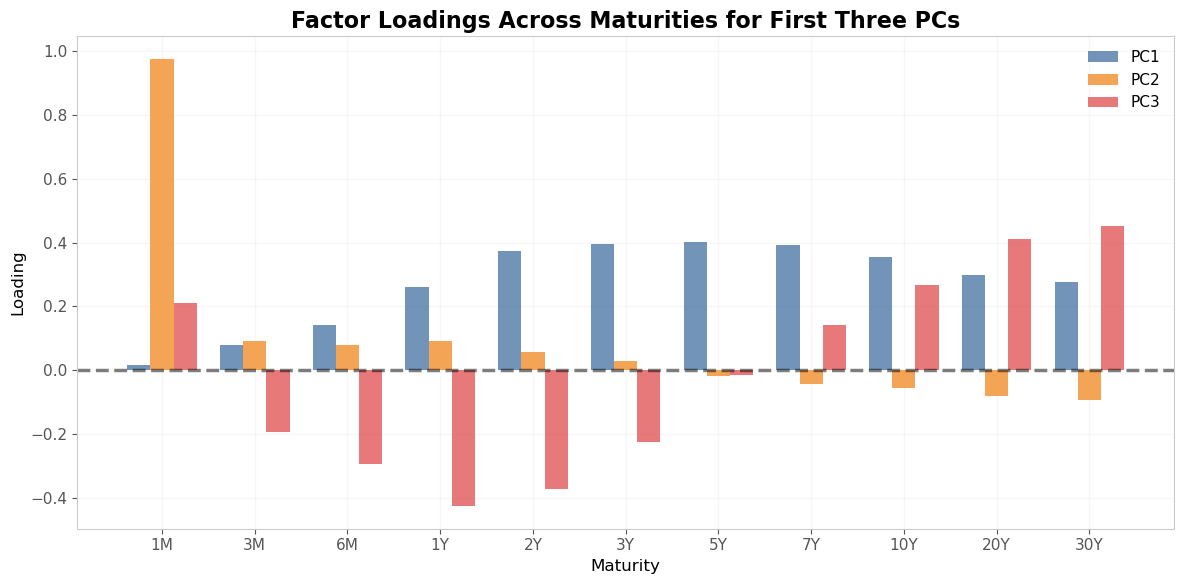


Interpretation:
PC1 (Level): Parallel shifts in yields across all maturities
PC2 (Slope): Changes in the steepness of the yield curve (short vs long)
PC3 (Curvature): Changes in the curvature (intermediate maturities vs short and long)


In [40]:
loadings = pca.components_.T
loadings_df = pd.DataFrame(loadings, index=yields_diff.columns, columns=[f'PC{i+1}' for i in range(loadings.shape[1])])

print("Factor Loadings:")
print(loadings_df.round(4))

maturities = list(yields_diff.columns)
maturity_order = ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']

loadings_subset = loadings_df[['PC1', 'PC2', 'PC3']].reindex(maturity_order)

fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.25
x = np.arange(len(maturity_order))

ax.bar(x - bar_width, loadings_subset['PC1'], width=bar_width, label='PC1', alpha=0.8)
ax.bar(x, loadings_subset['PC2'], width=bar_width, label='PC2', alpha=0.8)
ax.bar(x + bar_width, loadings_subset['PC3'], width=bar_width, label='PC3', alpha=0.8)

ax.set_xlabel('Maturity')
ax.set_ylabel('Loading')
ax.set_title('Factor Loadings Across Maturities for First Three PCs')
ax.set_xticks(x)
ax.set_xticklabels(maturity_order)
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("PC1 (Level): Parallel shifts in yields across all maturities")
print("PC2 (Slope): Changes in the steepness of the yield curve (short vs long)")
print("PC3 (Curvature): Changes in the curvature (intermediate maturities vs short and long)")

# Principal Component Time Series

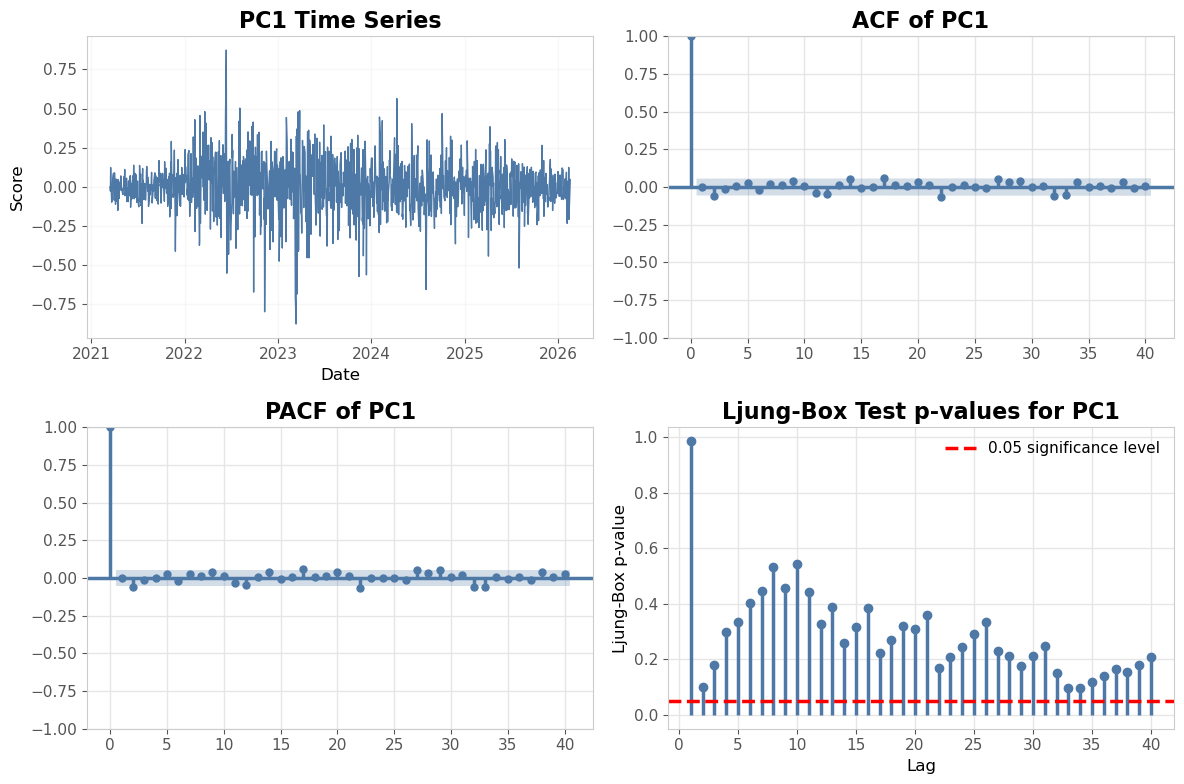


PC1 Persistence Analysis:
ACF at lag 1: -0.0005
ACF at lag 5: 0.0256
ACF at lag 10: 0.0087
Low persistence - weak serial correlation.


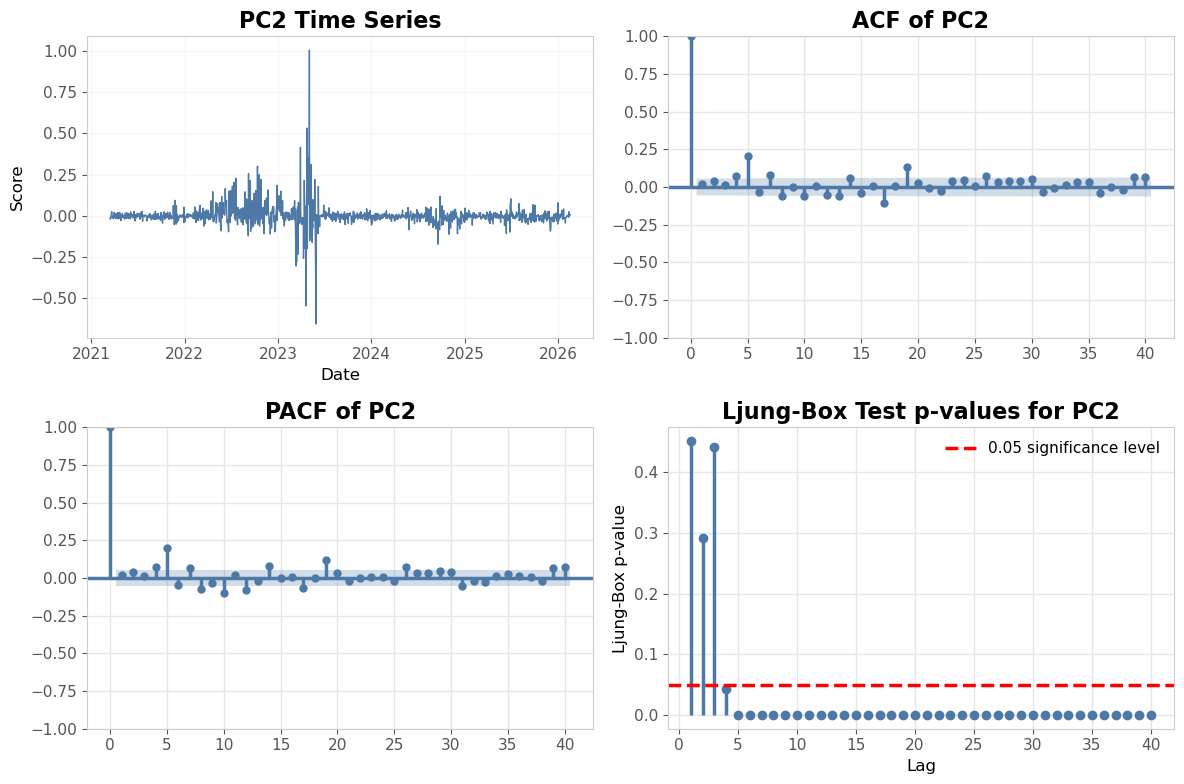


PC2 Persistence Analysis:
ACF at lag 1: 0.0214
ACF at lag 5: 0.2038
ACF at lag 10: -0.0613
Low persistence - weak serial correlation.


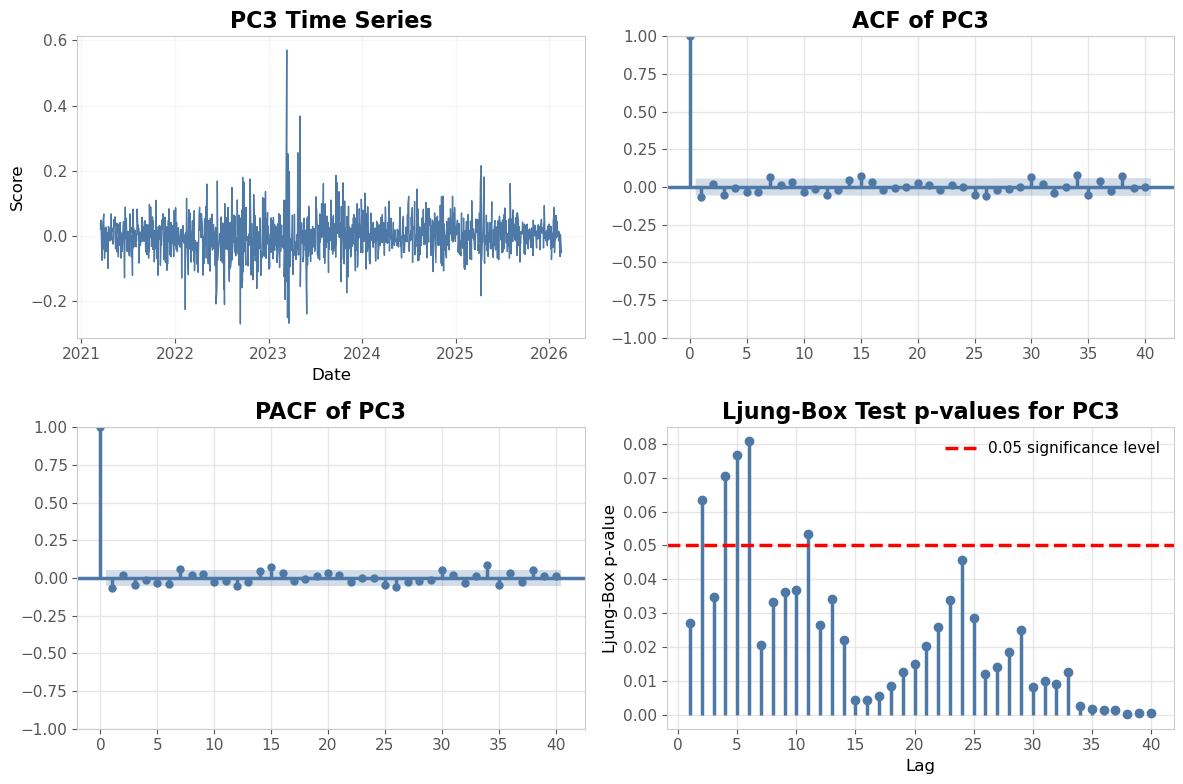


PC3 Persistence Analysis:
ACF at lag 1: -0.0629
ACF at lag 5: -0.0325
ACF at lag 10: -0.0331
Low persistence - weak serial correlation.


In [41]:
pc_scores = pca.transform(yields_diff)
pc_df = pd.DataFrame(pc_scores, index=yields_diff.index, columns=[f'PC{i+1}' for i in range(pc_scores.shape[1])])

for i in range(3):
    pc_name = f'PC{i+1}'
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    axes[0,0].plot(pc_df.index, pc_df[pc_name], linewidth=1)
    axes[0,0].set_title(f'{pc_name} Time Series')
    axes[0,0].set_xlabel('Date')
    axes[0,0].set_ylabel('Score')
    axes[0,0].grid(True, alpha=0.3)
    
    plot_acf(pc_df[pc_name].dropna(), lags=40, ax=axes[0,1])
    axes[0,1].set_title(f'ACF of {pc_name}')
    
    plot_pacf(pc_df[pc_name].dropna(), lags=40, ax=axes[1,0], method='ywm')
    axes[1,0].set_title(f'PACF of {pc_name}')
    
    lb_test = acorr_ljungbox(pc_df[pc_name].dropna(), lags=40, return_df=True)
    axes[1,1].stem(lb_test.index, lb_test['lb_pvalue'], basefmt=" ")
    axes[1,1].axhline(0.05, color='red', linestyle='--', label='0.05 significance level')
    axes[1,1].set_xlabel("Lag")
    axes[1,1].set_ylabel("Ljung-Box p-value")
    axes[1,1].set_title(f"Ljung-Box Test p-values for {pc_name}")
    axes[1,1].legend()
    
    plt.tight_layout()
    plt.show()
    
    acf_vals = acf(pc_df[pc_name].dropna(), nlags=20, fft=True)
    print(f"\n{pc_name} Persistence Analysis:")
    print(f"ACF at lag 1: {acf_vals[1]:.4f}")
    print(f"ACF at lag 5: {acf_vals[5]:.4f}")
    print(f"ACF at lag 10: {acf_vals[10]:.4f}")
    if acf_vals[1] > 0.5:
        print("High persistence - strong serial correlation.")
    elif acf_vals[1] > 0.2:
        print("Moderate persistence.")
    else:
        print("Low persistence - weak serial correlation.")

# ARMA and VAR Modeling of Principal Components

In [42]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import VAR

# ARMA modeling for each PC
arma_models = {}
for i in range(3):
    pc_name = f'PC{i+1}'
    series = pc_df[pc_name].dropna()
    
    # Fit ARMA(1,1) as example
    model = ARIMA(series, order=(1, 0, 1))
    fit = model.fit()
    arma_models[pc_name] = fit
    
    print(f"{pc_name} ARMA(1,1) Summary:")
    print(fit.summary())
    print("\n")

# VAR modeling on first 3 PCs
pc_subset = pc_df[['PC1', 'PC2', 'PC3']].dropna()
var_model = VAR(pc_subset)
var_results = var_model.fit(maxlags=5, ic='aic')
print("VAR Model Summary:")
print(var_results.summary())

# Forecast with VAR
forecast_steps = 10
var_forecast = var_results.forecast(pc_subset.values[-var_results.k_ar:], steps=forecast_steps)
var_forecast_df = pd.DataFrame(var_forecast, columns=['PC1', 'PC2', 'PC3'])
print("\nVAR Forecast (next 10 steps):")
print(var_forecast_df)

# Reconstruct yield changes from PC forecasts
reconstructed_changes = var_forecast_df.dot(loadings_df[['PC1', 'PC2', 'PC3']].T)
print("\nReconstructed Yield Changes Forecast:")
print(reconstructed_changes)

PC1 ARMA(1,1) Summary:
                               SARIMAX Results                                
Dep. Variable:                    PC1   No. Observations:                 1231
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 457.344
Date:                Sat, 14 Mar 2026   AIC                           -906.687
Time:                        11:48:10   BIC                           -886.225
Sample:                             0   HQIC                          -898.989
                               - 1231                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       9.695e-07      0.005      0.000      1.000      -0.009       0.009
ar.L1          0.6050      0.410      1.477      0.140      -0.198       1.408
ma.L1         -0.6298      0.

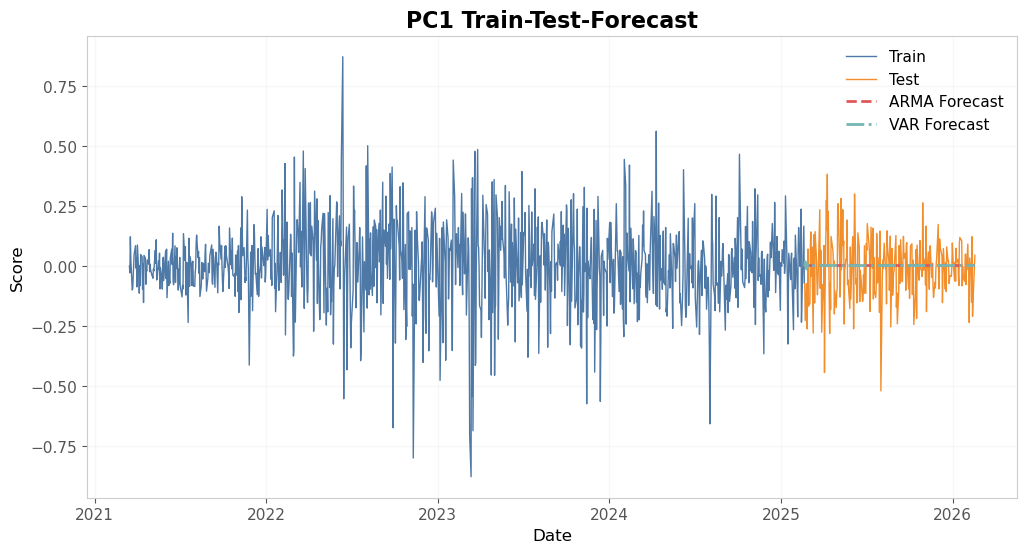

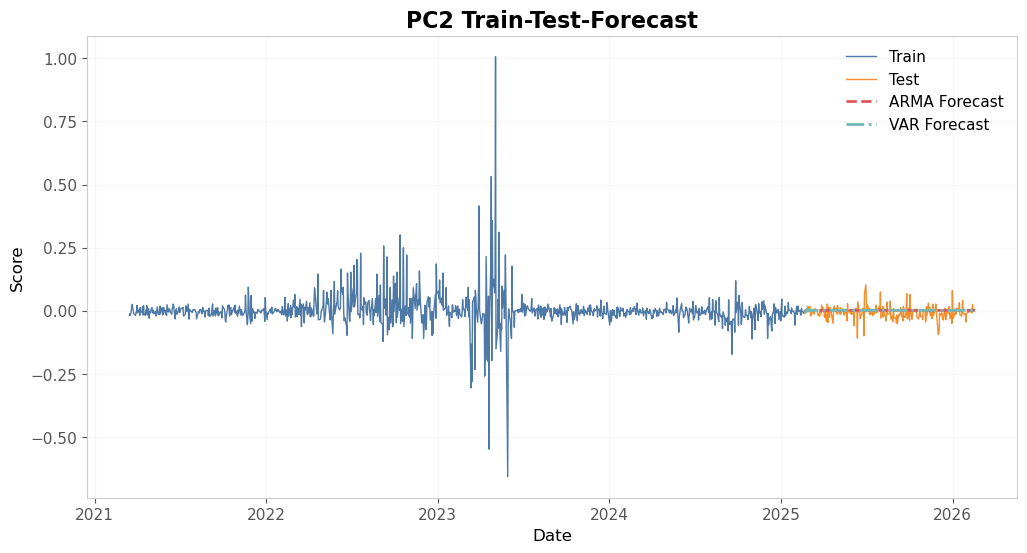

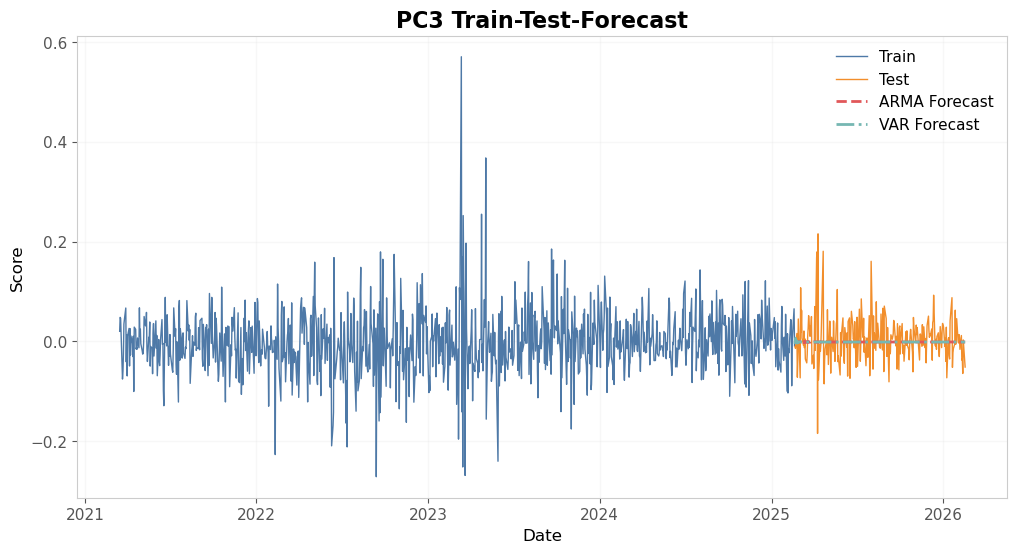

In [43]:
# Train-Test Split for Forecasting
test_size = 0.2
n = len(pc_df)
split_idx = int(n * (1 - test_size))
pc_train = pc_df.iloc[:split_idx]
pc_test = pc_df.iloc[split_idx:]

# ARMA Forecasting
arma_forecasts = {}
for i in range(3):
    pc_name = f'PC{i+1}'
    train_series = pc_train[pc_name].dropna()
    test_series = pc_test[pc_name].dropna()
    
    model = ARIMA(train_series, order=(1, 0, 1))
    fit = model.fit()
    
    forecast = fit.forecast(steps=len(test_series))
    arma_forecasts[pc_name] = forecast

# VAR Forecasting
pc_train_subset = pc_train[['PC1', 'PC2', 'PC3']].dropna()
pc_test_subset = pc_test[['PC1', 'PC2', 'PC3']].dropna()

var_model = VAR(pc_train_subset)
var_results = var_model.fit(maxlags=5, ic='aic')

var_forecast = var_results.forecast(pc_train_subset.values[-var_results.k_ar:], steps=len(pc_test_subset))
var_forecast_df = pd.DataFrame(var_forecast, index=pc_test_subset.index, columns=['PC1', 'PC2', 'PC3'])

# Plot Train-Test-Forecast for each PC
for i in range(3):
    pc_name = f'PC{i+1}'
    
    plt.figure(figsize=(12, 6))
    plt.plot(pc_train.index, pc_train[pc_name], label='Train', linewidth=1)
    plt.plot(pc_test.index, pc_test[pc_name], label='Test', linewidth=1)
    plt.plot(pc_test.index, arma_forecasts[pc_name], label='ARMA Forecast', linewidth=2, linestyle='--')
    plt.plot(pc_test.index, var_forecast_df[pc_name], label='VAR Forecast', linewidth=2, linestyle='-.')
    plt.title(f'{pc_name} Train-Test-Forecast')
    plt.xlabel('Date')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [44]:
# Forecast Accuracy Metrics
print("Forecast Accuracy Metrics:")
for i in range(3):
    pc_name = f'PC{i+1}'
    test_actual = pc_test[pc_name]
    arma_pred = arma_forecasts[pc_name]
    var_pred = var_forecast_df[pc_name]
    
    arma_rmse = np.sqrt(mean_squared_error(test_actual, arma_pred))
    var_rmse = np.sqrt(mean_squared_error(test_actual, var_pred))
    
    print(f"{pc_name} - ARMA RMSE: {arma_rmse:.4f}, VAR RMSE: {var_rmse:.4f}")

Forecast Accuracy Metrics:
PC1 - ARMA RMSE: 0.1267, VAR RMSE: 0.1267
PC2 - ARMA RMSE: 0.0269, VAR RMSE: 0.0269
PC3 - ARMA RMSE: 0.0460, VAR RMSE: 0.0460


In [ ]:
# In-sample Fit of ARMA on PCs
for i in range(3):
    pc_name = f'PC{i+1}'
    train_series = pc_train[pc_name].dropna()
    
    model = ARIMA(train_series, order=(1, 0, 1))
    fit = model.fit()
    fitted = fit.fittedvalues
    
    plt.figure(figsize=(12, 6))
    plt.plot(train_series.index, train_series, label='Actual', linewidth=1)
    plt.plot(fitted.index, fitted, label='ARMA Fitted', linewidth=2, linestyle='--')
    plt.title(f'{pc_name} ARMA In-sample Fit on Training Data')
    plt.xlabel('Date')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [45]:
# Check forecast values
print("Sample ARMA forecast values for PC1:")
print(arma_forecasts['PC1'].head(10))
print("Are they constant?", arma_forecasts['PC1'].std() < 1e-6)

Sample ARMA forecast values for PC1:
984    0.004626
985    0.004173
986    0.003914
987    0.003767
988    0.003682
989    0.003634
990    0.003607
991    0.003591
992    0.003582
993    0.003577
Name: predicted_mean, dtype: float64
Are they constant? False


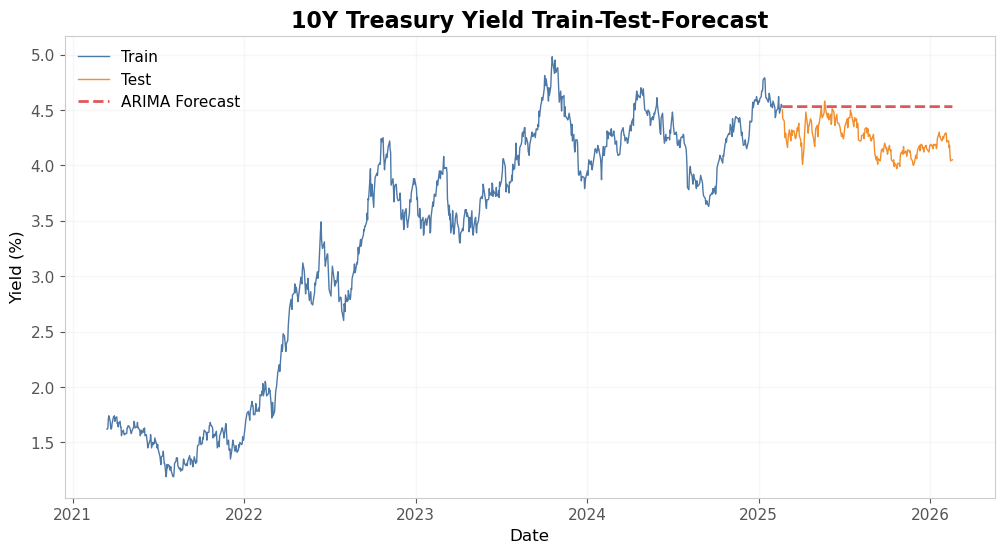

10Y Yield ARIMA RMSE: 0.3177


In [46]:
# Forecast Treasury Yield Directly (10Y as example)
yield_10y = yields['10Y'].dropna()

# Train-Test Split
test_size = 0.2
n = len(yield_10y)
split_idx = int(n * (1 - test_size))
train_yield = yield_10y.iloc[:split_idx]
test_yield = yield_10y.iloc[split_idx:]

# Fit ARIMA on levels (since yields are I(1), but differencing in ARIMA)
model = ARIMA(train_yield, order=(1, 1, 1))  # ARIMA(1,1,1) for differenced series
fit = model.fit()

forecast_yield = fit.forecast(steps=len(test_yield))

# Plot
plt.figure(figsize=(12, 6))
plt.plot(train_yield.index, train_yield, label='Train', linewidth=1)
plt.plot(test_yield.index, test_yield, label='Test', linewidth=1)
plt.plot(test_yield.index, forecast_yield, label='ARIMA Forecast', linewidth=2, linestyle='--')
plt.title('10Y Treasury Yield Train-Test-Forecast')
plt.xlabel('Date')
plt.ylabel('Yield (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Accuracy
rmse = np.sqrt(mean_squared_error(test_yield, forecast_yield))
print(f"10Y Yield ARIMA RMSE: {rmse:.4f}")

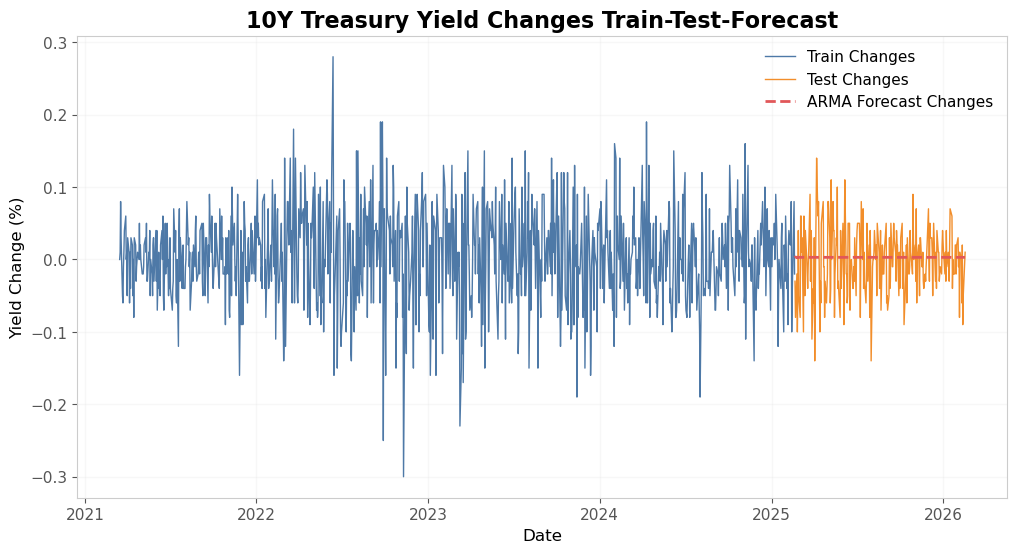

10Y Yield Changes ARMA RMSE: 0.0472


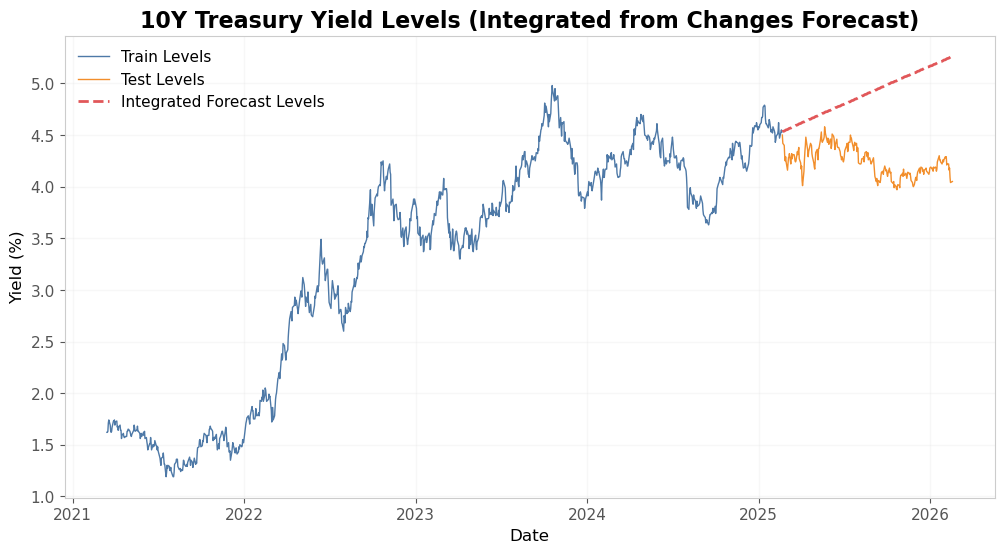

In [47]:
# Forecast 10Y Yield Changes (Differenced)
yield_10y_diff = yield_10y.diff().dropna()

# Train-Test Split on differenced
n_diff = len(yield_10y_diff)
split_idx_diff = int(n_diff * (1 - test_size))
train_diff = yield_10y_diff.iloc[:split_idx_diff]
test_diff = yield_10y_diff.iloc[split_idx_diff:]

# Fit ARMA on differenced (since already differenced, use ARMA(1,1))
model_diff = ARIMA(train_diff, order=(1, 0, 1))
fit_diff = model_diff.fit()

forecast_diff = fit_diff.forecast(steps=len(test_diff))

# Plot differenced
plt.figure(figsize=(12, 6))
plt.plot(train_diff.index, train_diff, label='Train Changes', linewidth=1)
plt.plot(test_diff.index, test_diff, label='Test Changes', linewidth=1)
plt.plot(test_diff.index, forecast_diff, label='ARMA Forecast Changes', linewidth=2, linestyle='--')
plt.title('10Y Treasury Yield Changes Train-Test-Forecast')
plt.xlabel('Date')
plt.ylabel('Yield Change (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Accuracy for changes
rmse_diff = np.sqrt(mean_squared_error(test_diff, forecast_diff))
print(f"10Y Yield Changes ARMA RMSE: {rmse_diff:.4f}")

# To get level forecast, integrate the changes (but approximate)
# Last train level + cumulative forecast changes
last_train_level = train_yield.iloc[-1]
forecast_levels = [last_train_level]
for change in forecast_diff:
    forecast_levels.append(forecast_levels[-1] + change)
forecast_levels = forecast_levels[1:]  # Remove initial

plt.figure(figsize=(12, 6))
plt.plot(train_yield.index, train_yield, label='Train Levels', linewidth=1)
plt.plot(test_yield.index, test_yield, label='Test Levels', linewidth=1)
plt.plot(test_yield.index, forecast_levels, label='Integrated Forecast Levels', linewidth=2, linestyle='--')
plt.title('10Y Treasury Yield Levels (Integrated from Changes Forecast)')
plt.xlabel('Date')
plt.ylabel('Yield (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()